In [188]:
import mujoco as mj
import mujoco.viewer
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

In [189]:
REPO_NAME = "preERP"

XML_RELATIVE_PATH = Path("mechanical/mujoco_assets/MyPalletizer260/MyPalletizer260.xml")

def find_repo_root(start: Path, name: str = REPO_NAME) -> Path:
    """Sube desde `start` hasta el ancestro llamado `name`.

    `start` incluido: si ya estas parado en el repo, no sube nada. Si el
    nombre no aparece, cae a la busqueda por marcador (pyproject.toml), que
    es lo que hace que esto siga funcionando si renombras la carpeta.
    """
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name.lower() == name.lower():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(
        f"No se encontro la carpeta '{name}' ni un pyproject.toml subiendo "
        f"desde {start}. Corre el notebook dentro del repo, o fija repo_root a mano."
    )


repo_root = find_repo_root(Path.cwd())
model_path = (repo_root / XML_RELATIVE_PATH).resolve()

if not model_path.is_file():
    raise FileNotFoundError(
        f"Repo root OK ({repo_root}), pero no existe {XML_RELATIVE_PATH} adentro."
        f"Buscado en: {model_path}"
    )

print(f"repo root:  {repo_root}")
print(f"Cargando modelo MuJoCo desde: {model_path}")

model = mj.MjModel.from_xml_path(str(model_path))
data = mj.MjData(model)
mj.mj_resetDataKeyframe(model, data, model.key("home").id)
dt = model.opt.timestep
print(f"Modelo cargado OK -> bodies: {model.nbody}, joints: {model.njnt}, "
      f"geoms: {model.ngeom}, actuadores: {model.nu}")
for j in range(model.njnt):
    print("  joint", j, mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j))

print("qpos0 =", model.qpos0,"\n qpos =", data.qpos)

repo root:  C:\Users\nicoa\Desktop\Universidad\ERP\preERP
Cargando modelo MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\mechanical\mujoco_assets\MyPalletizer260\MyPalletizer260.xml
Modelo cargado OK -> bodies: 6, joints: 4, geoms: 26, actuadores: 3
  joint 0 rot
  joint 1 link1
  joint 2 link2
  joint 3 act
qpos0 = [ 1.57   -3.1415  1.57    1.57  ] 
 qpos = [0.     0.     0.     1.5693]


### Trajectory

periodo 3.000 s (w = 2.094 rad/s), 1500 muestras a 500 Hz
pico de velocidad por junta [deg/s]: [62.8 20.9 41.9]  (spec del brazo: 120)


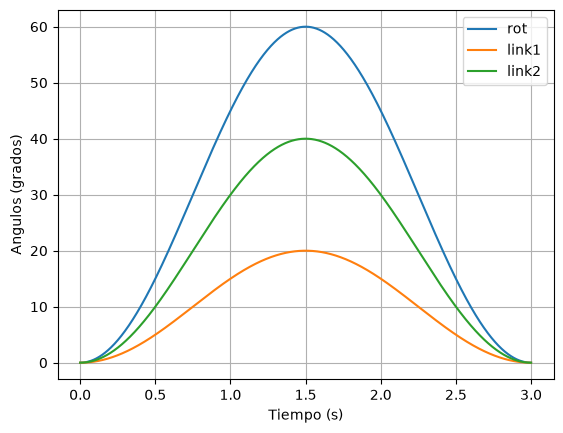

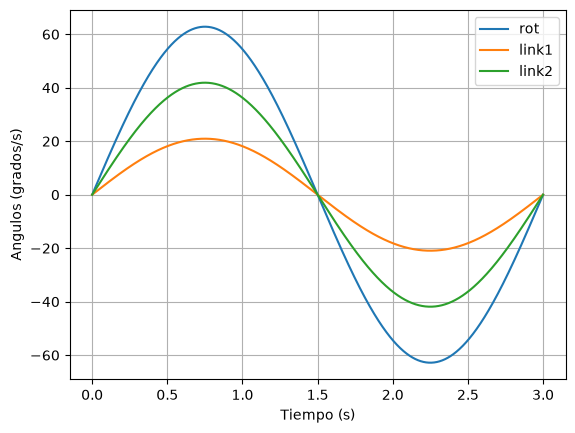

In [190]:
# --- 1. Trajectory Setup & Generation ---
#
# PERIODO_S es LA perilla de velocidad. Antes estaba implicita: `sin(i)` con
# `i` en segundos es w = 1 rad/s, y `sim_t = 2*pi` era justo un ciclo.
#
# NO CONFUNDIR CON `STREAM_RATE_HZ`. Esa es cada cuanto se manda un setpoint;
# subirla NO acelera el movimiento, solo manda mas puntos de la misma
# trayectoria. Si el brazo tiene que ir mas rapido, se acorta el periodo.
#
# La amplitud no cambia con el periodo, asi que los limites de POSICION siguen
# dando OK. Lo que escala es la VELOCIDAD, como A*w = 2*pi*A/PERIODO_S:
#
#   PERIODO_S   pico J1/J2/J3 [deg/s]   muestras/ciclo a 25 Hz   RMS J1 MuJoCo
#     6.283          30 / 10 / 20               157                 5.97 deg
#     4.0            47 / 16 / 31               100                 8.93 deg
#     3.0            63 / 21 / 42                75                11.26 deg
#     2.0            94 / 31 / 63                50                14.89 deg
#     1.571         120 / 40 / 80                39                17.07 deg
#
# 1.571 s es el PISO DURO: ahi J1 toca los 120 deg/s de spec del brazo
# (2*pi*30/120). `check_trajectory` valida la velocidad y frena antes de eso.
#
# El costo de ir rapido no es el par: medido, los servos no pasan del 10% de su
# `forcerange` en ningun caso. Es el ATRASO. El RMS de J1 en MuJoCo se
# triplica, porque `rot_servo` tiene kp=1.62 contra kp=63.35 de link1; y los
# ~143 ms de retardo del brazo, que a 6.283 s son 8 deg de fase, a 2 s son 26.

PERIODO_S = 3                # segundos por ciclo. Antes: 2*np.pi = 6.283
w = 2 * np.pi / PERIODO_S       # rad/s

dt = model.opt.timestep
sim_t = PERIODO_S
n_samples = int(sim_t / dt)
t = np.linspace(0, sim_t, n_samples)

amplitudes = np.deg2rad(np.array([30, 10, 20]))

# Vectorizado y como arrays desde el arranque. Esta es la UNICA definicion de
# la trayectoria: la celda de abajo la regeneraba con la formula vieja, que es
# como un cambio de periodo aca quedaba silenciosamente pisado.
q_target = np.sin(w * t - np.pi / 2)[:, None] * amplitudes + amplitudes
qd_target = amplitudes * w * np.cos(w * t - np.pi / 2)[:, None]
#                        ^^^ regla de la cadena. Sin el factor w la velocidad
# queda mal por ese factor y el grafico no lo delata: sigue siendo un coseno
# de la forma correcta, solo que con la escala equivocada.

print(f"periodo {PERIODO_S:.3f} s (w = {w:.3f} rad/s), "
      f"{n_samples} muestras a {1 / dt:.0f} Hz")
print("pico de velocidad por junta [deg/s]:",
      np.round(np.rad2deg(amplitudes * w), 1), " (spec del brazo: 120)")

plt.figure()
plt.plot(t, np.rad2deg(q_target))
plt.grid()
plt.ylabel("Angulos (grados)")
plt.xlabel("Tiempo (s)")
plt.legend(["rot", "link1", "link2"])

plt.figure()
plt.plot(t, np.rad2deg(qd_target))
plt.grid()
plt.ylabel("Angulos (grados/s)")
plt.xlabel("Tiempo (s)")
plt.legend(["rot", "link1", "link2"])

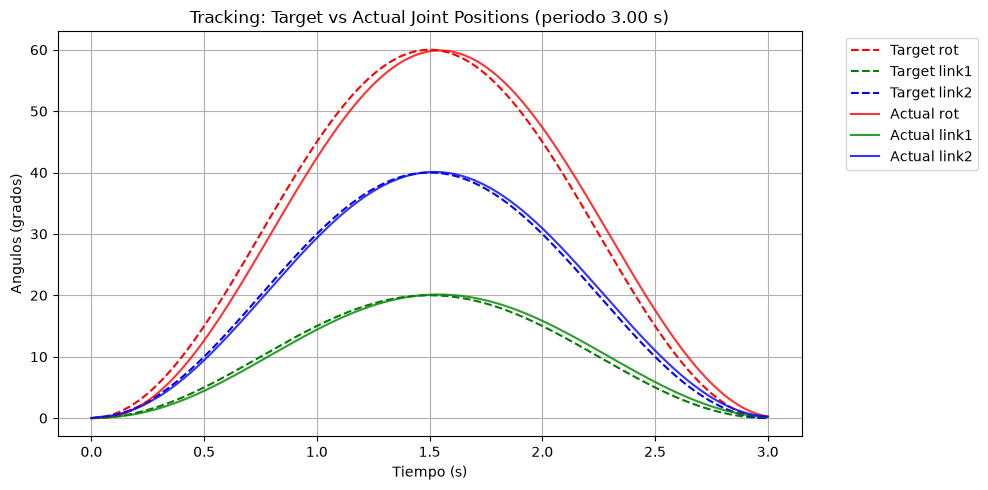

Showing video at 60 FPS...  (3.00 s por ciclo)


This browser does not support the video tag.


In [191]:
# --- 1. Simulacion y video de la MISMA trayectoria armada arriba ---
video_fps = 60                     # Target FPS for the output video

# Aca habia una SEGUNDA copia de la generacion de la trayectoria. La saque:
# regeneraba q_target con w = 1 rad/s fijo, asi que cambiar PERIODO_S en la
# celda de arriba no tenia ningun efecto -- esta celda lo pisaba con la version
# lenta y el video salia igual de lento, sin ninguna senal de por que.
# q_target / qd_target vienen de la celda anterior y son la unica definicion.

# --- 2. Simulation Setup ---
# Reset to 'home' keyframe initial position
mj.mj_resetDataKeyframe(model, data, model.key("home").id)

renderer = mj.Renderer(model, height=480, width=640)

# --- 3. Run Simulation & Capture Frames ---
qpos_log = []
frames = []
sensor_log = np.empty((n_samples, 15), dtype=np.float64)
# Keep track of simulation time to render exactly at 60 FPS
last_render_time = data.time - 1.0 

for i in range(n_samples):
    # Set position target to actuators [rot_servo, link1_servo, link2_servo]
    data.ctrl[:3] = q_target[i]
    link1_acc  = data.sensor('link1_acc').data    # shape (3,)
    link2_acc  = data.sensor('link2_acc').data    # shape (3,)
    link1_gyro = data.sensor('link1_gyro').data   # shape (3,)
    link2_gyro = data.sensor('link2_gyro').data   # shape (3,)
    efector_pos = data.sensor('efector_pos').data  # shape (3,)

    sensor_log[i] = data.sensordata

    # Step simulation
    mj.mj_step(model, data)
    
    # Log actual joint positions every simulation step (rot, link1, link2)
    qpos_log.append(data.qpos[:3].copy())
    
    # Render frame ONLY if 1/60th of a second has passed in simulation time
    if data.time - last_render_time >= 1.0 / video_fps:
        renderer.update_scene(data, camera="tracking_cam")
        frames.append(renderer.render())
        last_render_time = data.time

qpos_log = np.array(qpos_log)

# --- Post-Processing (Extract individual sensors after the loop) ---
link1_acc_history  = sensor_log[:, 0:3]
link2_acc_history  = sensor_log[:, 3:6]
link1_gyro_history = sensor_log[:, 6:9]   # Primary signal for clock sync
link2_gyro_history = sensor_log[:, 9:12]
efector_pos_history = sensor_log[:, 12:15]

# --- 4. Plot Target vs Actual qpos ---
plt.figure(figsize=(10, 5))

# Target Joint Angles
plt.plot(t, np.rad2deg(q_target[:, 0]), 'r--', label="Target rot")
plt.plot(t, np.rad2deg(q_target[:, 1]), 'g--', label="Target link1")
plt.plot(t, np.rad2deg(q_target[:, 2]), 'b--', label="Target link2")

# Actual Joint Angles
plt.plot(t, np.rad2deg(qpos_log[:, 0]), 'r-', alpha=0.8, label="Actual rot")
plt.plot(t, np.rad2deg(qpos_log[:, 1]), 'g-', alpha=0.8, label="Actual link1")
plt.plot(t, np.rad2deg(qpos_log[:, 2]), 'b-', alpha=0.8, label="Actual link2")

plt.grid(True)
plt.ylabel("Angulos (grados)")
plt.xlabel("Tiempo (s)")
plt.title(f"Tracking: Target vs Actual Joint Positions (periodo {PERIODO_S:.2f} s)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 5. Show Video via Mediapy ---
# El video sale en TIEMPO REAL: se captura un frame cada 1/60 s de tiempo de
# simulacion y se reproduce a 60 fps. Asi que lo que se ve en el video es la
# velocidad que va a tener el brazo -- ese es el punto de comparacion.
print(f"Showing video at {video_fps} FPS...  ({PERIODO_S:.2f} s por ciclo)")
media.show_video(frames, fps=video_fps)
renderer.close()

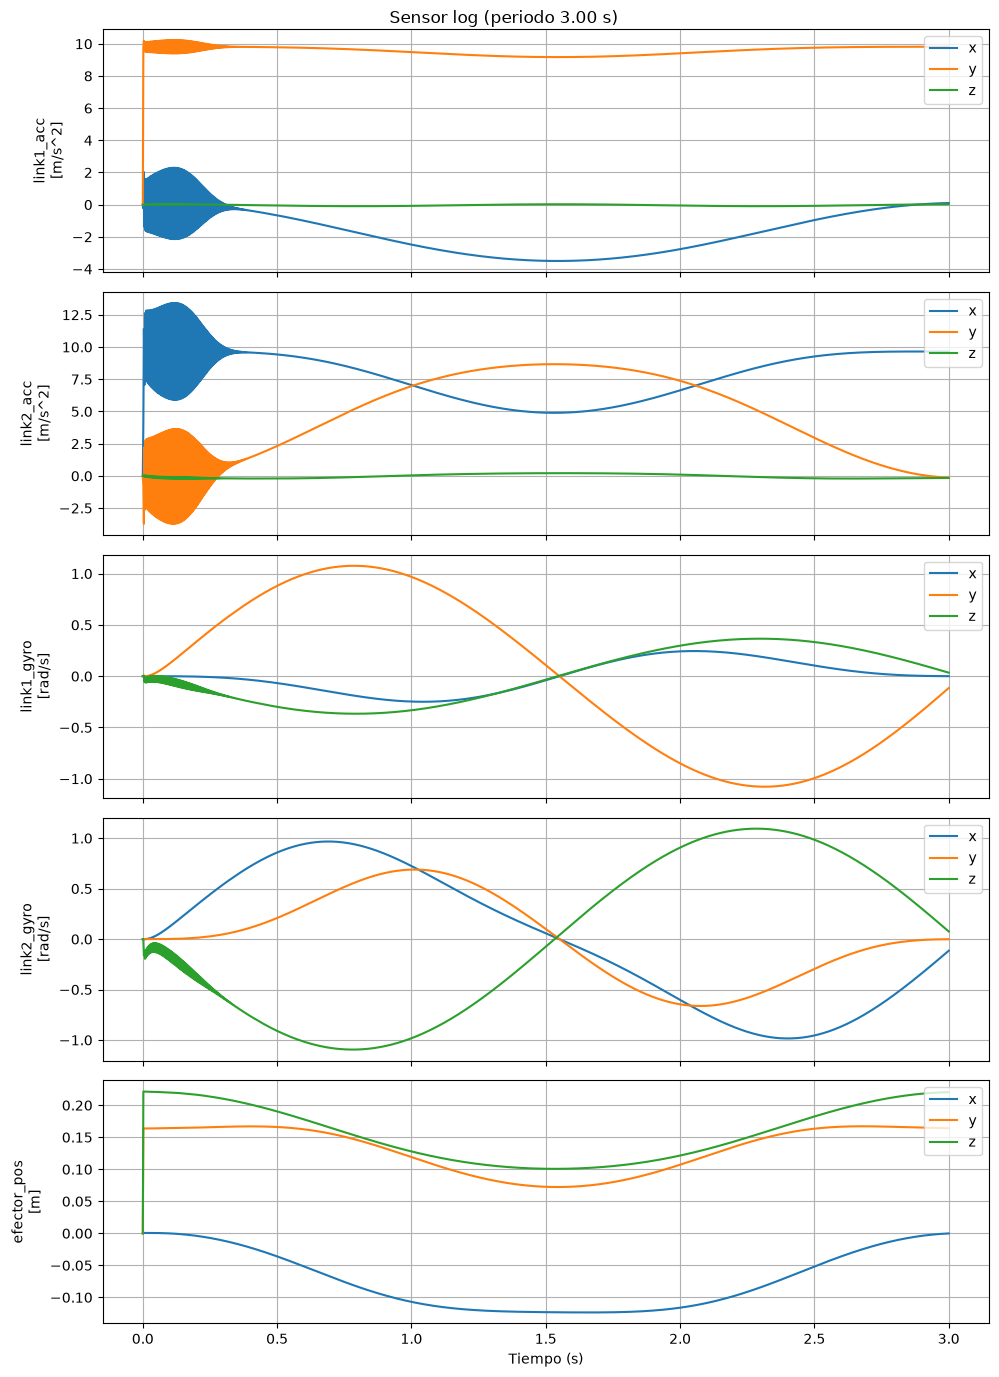

In [192]:
# --- 6. Plot Sensor Log ---
# link1_acc/link2_acc: m/s^2, sensor frame (MuJoCo accelerometer, includes gravity)
# link1_gyro/link2_gyro: rad/s, sensor frame
# efector_pos: m, world frame

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

axes[0].plot(t, link1_acc_history)
axes[0].set_ylabel("link1_acc\n[m/s^2]")
axes[0].legend(["x", "y", "z"], loc="upper right")

axes[1].plot(t, link2_acc_history)
axes[1].set_ylabel("link2_acc\n[m/s^2]")
axes[1].legend(["x", "y", "z"], loc="upper right")

axes[2].plot(t, link1_gyro_history)
axes[2].set_ylabel("link1_gyro\n[rad/s]")
axes[2].legend(["x", "y", "z"], loc="upper right")

axes[3].plot(t, link2_gyro_history)
axes[3].set_ylabel("link2_gyro\n[rad/s]")
axes[3].legend(["x", "y", "z"], loc="upper right")

axes[4].plot(t, efector_pos_history)
axes[4].set_ylabel("efector_pos\n[m]")
axes[4].set_xlabel("Tiempo (s)")
axes[4].legend(["x", "y", "z"], loc="upper right")

for ax in axes:
    ax.grid(True)

fig.suptitle(f"Sensor log (periodo {PERIODO_S:.2f} s)")
fig.tight_layout()
plt.show()

### Brazo fisico: planificada vs. robot real vs. MuJoCo

Manda la MISMA trayectoria de arriba al brazo real y compara las tres series.

**La cuarta junta no es la misma en los dos lados.** En el XML `act` es el
paralelogramo pasivo (sin actuador, lo mueve la igualdad de tendon
`mantener_vertical`); en el brazo real ese paralelogramo es mecanico y J4 es el
giro del efector. Asi que `data.qpos[3]` no se manda nunca, `get_angles()[3]`
no tiene con que compararse, y **solo 3 de las 4 juntas son comparables**.

Los ceros del modelo y del robot ya estan verificados fisicamente, asi que el
mapeo modelo -> API es identidad en grados.

Nada de esto abre un puerto serie: el default es `DryRunArm`, y la celda que
manda al robot esta detras de `SEND_TO_ROBOT = False`.

In [193]:
# ===========================================================================
# Mapeo de juntas, limites y guarda de rango.
# ===========================================================================
#
#   API J1 <-> XML `rot`     base, yaw
#   API J2 <-> XML `link1`   hombro
#   API J3 <-> XML `link2`   codo
#   API J4 <-> NADA          ver la celda de arriba: la cuarta junta del XML es
#                            `act`, el paralelogramo pasivo, no J4.
#
# POR QUE HAY UNA GUARDA PROPIA Y NO ALCANZA LA DE pymycobot. La libreria NO
# valida los angulos en esta clase: `send_angles` pasa `angles=...` y
# `send_angle` pasa `angle=...`, pero `MyPalletizer260.calibration_parameters`
# solo mira los kwargs `degrees` y `degree`. Los chequeos nunca se disparan --
# solo `id` y `speed` se validan de verdad, y la cota de la clase es +-170 deg,
# mucho mas ancha que los limites reales de cada junta. Un valor fuera de rango
# llega al firmware sin que nadie lo mire.
#
# SIGNS/OFFSETS quedan explicitos aunque hoy sean identidad: si alguna vez se
# invierte una junta se cambia aca, y la guarda lo atrapa antes de mover nada
# (una J2 invertida barre 0 -> -20 deg, fuera del piso de -2 deg de J2).

from collections import deque

API_LIMITS_DEG = {1: (-162.0, 162.0),   # rot   / base
                  2: (  -2.0,  90.0),   # link1 / hombro
                  3: ( -92.0,  60.0),   # link2 / codo
                  4: (-180.0, 180.0)}   # efector, sin modelar

JOINT_NAMES = ["rot", "link1", "link2"]
API_IDS     = [1, 2, 3]
SIGNS       = np.array([1.0, 1.0, 1.0])   # ceros verificados fisicamente
OFFSETS_DEG = np.array([0.0, 0.0, 0.0])
J4_HOLD_DEG = 0.0                          # J4 se mantiene fijo, no se barre
VMAX_DEG_S  = 120.0                        # spec del brazo, igual que viewer.ipynb


def model_to_api_deg(q_rad):
    """(N,3) rad del modelo (rot, link1, link2) -> (N,4) grados de la API.

    La cuarta columna es J4 constante en `J4_HOLD_DEG`: la API pide 4 valores
    y el modelo solo tiene 3 juntas actuadas.
    """
    q = np.atleast_2d(np.asarray(q_rad, dtype=float))
    deg = np.rad2deg(q) * SIGNS + OFFSETS_DEG
    return np.column_stack([deg, np.full(len(deg), J4_HOLD_DEG)])


def api_deg_to_model(deg):
    """(N,4) grados de la API -> (N,3) rad del modelo. Descarta J4."""
    d = np.atleast_2d(np.asarray(deg, dtype=float))[:, :3]
    return np.deg2rad((d - OFFSETS_DEG) / SIGNS)


def check_trajectory(q_rad, model, t=None, vmax_deg_s=VMAX_DEG_S, verbose=True):
    """Valida posiciones contra XML+API y, si le pasas `t`, tambien velocidad.

    q_rad: (N,3) en rad, en coordenadas del MODELO.
    t:     (N,) en s. Sin `t` no se puede chequear velocidad y se avisa.

    Levanta ValueError antes de que nada llegue al puerto serie. Los rangos del
    XML se leen del modelo cargado, no se copian, asi que la tabla sigue siendo
    cierta si cambian los `range` del XML.

    EL CHEQUEO DE VELOCIDAD IMPORTA AL ACELERAR. Acortar el periodo no cambia
    ni una posicion -- la amplitud es la misma -- asi que la tabla de posicion
    sigue dando OK mientras el pico de velocidad crece como 1/periodo. Sin este
    chequeo, la unica guarda que hay es ciega justo al parametro que se toca.
    """
    q = np.atleast_2d(np.asarray(q_rad, dtype=float))
    if q.shape[1] != 3:
        raise ValueError(f"La trayectoria tiene {q.shape[1]} columnas; se esperan 3 "
                         "(rot, link1, link2). qpos[3] es `act` y no se manda.")
    api = model_to_api_deg(q)

    rows, bad = [], []
    for k, name in enumerate(JOINT_NAMES):
        jid = API_IDS[k]
        lo_xml, hi_xml = np.rad2deg(model.jnt_range[k])
        lo_api, hi_api = API_LIMITS_DEG[jid]
        lo, hi = api[:, k].min(), api[:, k].max()
        ok_xml = (not model.jnt_limited[k]) or (lo >= lo_xml - 1e-9 and hi <= hi_xml + 1e-9)
        ok_api = lo >= lo_api and hi <= hi_api
        rows.append((jid, name, lo, hi, lo_xml, hi_xml, lo_api, hi_api, ok_xml, ok_api))
        if not ok_xml:
            bad.append(f"J{jid}/{name}: recorrido [{lo:.1f},{hi:.1f}] deg fuera del "
                       f"rango del XML [{lo_xml:.1f},{hi_xml:.1f}]")
        if not ok_api:
            bad.append(f"J{jid}/{name}: recorrido [{lo:.1f},{hi:.1f}] deg fuera del "
                       f"limite de la API [{lo_api:.1f},{hi_api:.1f}]")

    if t is not None:
        t = np.asarray(t, dtype=float)
        qd = np.abs(np.gradient(np.rad2deg(q), t, axis=0)).max(axis=0)
        for k, name in enumerate(JOINT_NAMES):
            if qd[k] > vmax_deg_s + 1e-9:
                bad.append(f"J{API_IDS[k]}/{name}: pico de velocidad "
                           f"{qd[k]:.1f} deg/s sobre la spec del brazo "
                           f"({vmax_deg_s:.0f} deg/s) -- alarga PERIODO_S")
    else:
        qd = None

    if verbose:
        print(f"{'API':>4} {'XML':<7}{'recorrido (deg)':>18}{'rango XML':>18}"
              f"{'limite API':>18}{'pico deg/s':>12}   veredicto")
        for jid, name, lo, hi, lx, hx, la, ha, oxml, oapi in rows:
            k = API_IDS.index(jid)
            ok_v = qd is None or qd[k] <= vmax_deg_s + 1e-9
            v = "OK" if (oxml and oapi and ok_v) else "FUERA DE RANGO"
            vel = f"{qd[k]:11.1f}" if qd is not None else f"{'(sin t)':>11}"
            print(f"J{jid:<3} {name:<7}[{lo:7.1f},{hi:7.1f}]  [{lx:7.1f},{hx:7.1f}]  "
                  f"[{la:7.1f},{ha:7.1f}]{vel}   {v}")
        print(f"J4   {'-':<7}{'(sin modelar)':>18}{'-':>18}{'[ -180.0, 180.0]':>18}"
              f"{'-':>12}   se mantiene en {J4_HOLD_DEG:.1f} deg")
        if qd is None:
            print("  OJO: sin `t` no se chequeo la velocidad. Pasale el eje de "
                  "tiempo: check_trajectory(q, model, t).")
        else:
            print(f"  spec de velocidad del brazo: {vmax_deg_s:.0f} deg/s")

    if bad:
        raise ValueError("Trayectoria fuera de rango, no se manda nada:\n  - "
                         + "\n  - ".join(bad))
    return api


def resample(t, q, rate_hz):
    """Baja la trayectoria de 500 Hz a algo que entre por el puerto serie.

    Los 3141 puntos a dt=2 ms no son transmisibles: a 115200 baud y con un
    protocolo de pedido/respuesta no hay forma. ~25 Hz deja ~157 setpoints.
    """
    q = np.asarray(q, dtype=float)   # la celda 3 deja q_target como lista
    n = max(2, int(round((t[-1] - t[0]) * rate_hz)) + 1)
    t_r = np.linspace(t[0], t[-1], n)
    q_r = np.column_stack([np.interp(t_r, t, q[:, k]) for k in range(q.shape[1])])
    return t_r, q_r

In [194]:
# ===========================================================================
# Los dos brazos. Misma interfaz: send(q_rad) / read() -> (4,) grados / close().
# Mismo reparto que ReplaySensor vs DummySensor en `erp`: el codigo de arriba no
# sabe cual de los dos tiene enchufado.
# ===========================================================================

class DryRunArm:
    """Brazo simulado. NO abre ningun puerto serie.

    Modela el firmware como un lag de primer orden hacia la consigna
    RETARDADA, con tope de velocidad. No pretende ser el robot: existe para que
    todo lo demas -- el bucle de streaming, el registro, los graficos, el
    estimador de retardo -- se pueda correr y falsificar con el brazo
    desenchufado.

    latency_s:      retardo de transporte, s (consigna -> se empieza a mover)
    tau_s:          constante del lag de primer orden, s
    rate_limit_dps: tope de velocidad, deg/s
    resolution_deg: cuantizacion de la lectura. 0.01 deg es la de verdad: la
                    API transmite `int(grados * 100)` (`_angle2int`).

    El lag de primer orden no es cosmetico. Con un ZOH puro contra la consigna
    retardada, el retardo (80 ms) late contra el periodo de envio (40 ms) y la
    lectura alterna entre dos setpoints: en el grafico salen DOS bandas
    paralelas que parecen un bug del registro y no lo son. Un servo con
    realimentacion de posicion no hace eso.
    """

    def __init__(self, latency_s=0.08, tau_s=0.06, rate_limit_dps=120.0,
                 resolution_deg=0.01):
        self.latency_s = float(latency_s)
        self.tau_s = float(tau_s)
        self.rate_limit_dps = float(rate_limit_dps)
        self.resolution_deg = float(resolution_deg)
        self._queue = deque()
        self._setpoint = np.zeros(4)
        self._state = np.zeros(4)      # arranca en `home` = [0,0,0] deg
        self._t_prev = time.perf_counter()
        self.name = (f"DryRunArm(latencia={latency_s * 1e3:.0f} ms, "
                     f"tau={tau_s * 1e3:.0f} ms, vmax={rate_limit_dps:.0f} deg/s)")

    def _advance(self, now):
        while self._queue and self._queue[0][0] <= now:
            self._setpoint = self._queue.popleft()[1]
        dt = max(0.0, now - self._t_prev)
        self._t_prev = now
        move = (self._setpoint - self._state) * (1.0 - np.exp(-dt / self.tau_s))
        cap = self.rate_limit_dps * dt
        self._state = self._state + np.clip(move, -cap, cap)

    def send(self, q_rad, speed=100):
        now = time.perf_counter()
        self._advance(now)
        self._queue.append((now + self.latency_s, model_to_api_deg(q_rad)[0]))

    def read(self):
        self._advance(time.perf_counter())
        return np.round(self._state / self.resolution_deg) * self.resolution_deg

    def close(self):
        pass


class SerialArm:
    """Brazo real via pymycobot. Solo se instancia si vos lo pedis.

    ESCRITURA. Por defecto `send_radians`, que escribe y vuelve. `send_angles`
    usa `has_reply=True`: BLOQUEA esperando la respuesta del firmware en cada
    setpoint, y eso a 25 Hz no entra. El precio de `send_radians` es que no
    consume esa respuesta, asi que si el firmware contesta igual, los bytes
    quedan en el buffer de entrada y el `get_angles()` siguiente puede leer
    basura. Si la lectura vuelve rara, poner `blocking_send=True` y bajar
    `rate_hz` -- se pierde tasa pero el protocolo queda sincronizado.

    `MyPalletizer260` NO tiene `set_fresh_mode` (si lo tiene MyCobot280), asi
    que los setpoints pueden ENCOLARSE en el firmware en vez de reemplazarse, y
    el atraso se acumula. No hay forma de arreglarlo desde el host: por eso
    `plot_three_way` MIDE el retardo en vez de suponer que no existe.
    """

    def __init__(self, port, speed=100, baudrate="115200", blocking_send=False):
        from pymycobot import MyPalletizer260
        self.mc = MyPalletizer260(port, baudrate=baudrate)
        self.speed = int(speed)
        self.blocking_send = bool(blocking_send)
        self.name = f"SerialArm({port}, speed={speed}, blocking_send={blocking_send})"

    def send(self, q_rad, speed=None):
        deg = model_to_api_deg(q_rad)[0]
        sp = self.speed if speed is None else int(speed)
        if self.blocking_send:
            self.mc.send_angles([float(d) for d in deg], sp)
        else:
            # send_radians convierte a grados adentro; le pasamos los grados de
            # la API en radianes para que la conversion de vuelta sea exacta.
            self.mc.send_radians([float(r) for r in np.deg2rad(deg)], sp)

    def read(self):
        """(4,) grados de la API, o None si la respuesta no vino / vino corta."""
        a = self.mc.get_angles()
        if not isinstance(a, (list, tuple)) or len(a) < 3:
            return None                     # get_angles devuelve -1 en error
        out = np.zeros(4)
        out[:min(4, len(a))] = a[:4]
        return out

    def close(self):
        try:
            self.mc._serial_port.close()
        except Exception:
            pass

In [195]:
# ===========================================================================
# Bucle de streaming, replay en MuJoCo, y estimador de retardo.
# ===========================================================================

def run_trajectory(arm, t, q_rad, rate_hz=25.0, speed=100, read=True,read_every=10, verbose=True):
    """Manda la trayectoria al brazo y registra consigna y medida POR SEPARADO.

    Devuelve un dict con `t_cmd`/`q_cmd_deg` (lo que se mando, sellado justo
    ANTES de escribir) y `t_meas`/`q_meas_deg` (lo que devolvio la lectura,
    sellado justo DESPUES de leer). Los tiempos son segundos desde el arranque
    del barrido; los angulos, grados de la API.

    Dos reglas, las mismas que documenta `SimLog` en viewer.ipynb:

    1. Cada muestra se sella con `time.perf_counter()` en el momento de la
       llamada. NUNCA se asume que la tasa nominal se cumplio: `time.sleep` en
       Windows tiene granularidad de milisegundos y el puerto serie agrega lo
       suyo. La tasa lograda y el jitter se miden y se informan.
    2. Consigna y medida quedan como series distintas, con ejes de tiempo
       distintos. Estan separadas por un viaje de ida y vuelta del puerto:
       meterlas en la misma fila como si fueran del mismo instante es
       exactamente el sesgo de un paso contra el que avisa `SimLog`, y no se ve
       en el grafico -- aparece despues como sesgo del filtro.
    """
    t_r, q_r = resample(t, q_rad, rate_hz)
    t_cmd = np.empty(len(t_r))
    q_cmd = np.empty((len(t_r), 4))
    t_meas, q_meas = [], []

    t0 = time.perf_counter()
    for i in range(len(t_r)):
        deadline = t0 + t_r[i]
        now = time.perf_counter()
        if now < deadline:
            time.sleep(deadline - now)
        t_cmd[i] = time.perf_counter() - t0
        q_cmd[i] = model_to_api_deg(q_r[i])[0]
        arm.send(q_r[i], speed=speed)
        if read:
            if i % read_every == 0:
                m = arm.read()
                if m is not None:
                    t_meas.append(time.perf_counter() - t0)
                    q_meas.append(m)

    gaps = np.diff(t_cmd)
    log = dict(t_cmd=t_cmd, q_cmd_deg=q_cmd,
               t_meas=np.asarray(t_meas),
               q_meas_deg=np.asarray(q_meas) if q_meas else np.empty((0, 4)),
               rate_nominal=rate_hz,
               rate_achieved=(len(t_cmd) - 1) / (t_cmd[-1] - t_cmd[0]),
               jitter_ms=float(np.std(gaps) * 1e3),
               arm=getattr(arm, "name", str(arm)))
    if verbose:
        print(log["arm"])
        print(f"  setpoints enviados : {len(t_cmd)} en {t_cmd[-1]:.3f} s")
        print(f"  tasa nominal       : {rate_hz:.1f} Hz")
        print(f"  tasa lograda       : {log['rate_achieved']:.2f} Hz "
              f"(jitter {log['jitter_ms']:.2f} ms, peor hueco {gaps.max() * 1e3:.1f} ms)")
        print(f"  lecturas recibidas : {len(t_meas)}")
        if read and len(t_meas) < len(t_cmd) // 2:
            print("  OJO: se perdieron mas de la mitad de las lecturas. Con "
                  "SerialArm suele ser el buffer desincronizado -> probar "
                  "blocking_send=True y menos rate_hz.")
    return log


def simulate(model, data, t, q_rad):
    """Repite los MISMOS setpoints en MuJoCo, a paso de fisica.

    Devuelve (t_sim, q_sim): tiempo de simulacion y qpos[:3] en rad, ambos
    POSTERIORES al paso. Se devuelve `data.time` en vez de reusar `t` porque
    qpos ya es de t+dt cuando `mj_step` vuelve; con el eje propio las dos
    mitades quedan etiquetadas con el instante que de verdad les corresponde.
    """
    q_rad = np.asarray(q_rad, dtype=float)   # idem: puede venir como lista
    mj.mj_resetDataKeyframe(model, data, model.key("home").id)
    t_sim = np.empty(len(t))
    q_sim = np.empty((len(t), 3))
    for i in range(len(t)):
        data.ctrl[:3] = q_rad[i]
        mj.mj_step(model, data)
        t_sim[i] = data.time
        q_sim[i] = data.qpos[:3]
    return t_sim, q_sim


def estimate_lag(t_ref, q_ref_deg, t_meas, q_meas_deg, max_lag_s=0.6, n=241):
    """Retardo, en s, que mejor alinea la medida con la consigna (RMS minimo).

    Positivo = la medida va ATRASADA respecto de la consigna. Se barre el
    retardo y se interpola la consigna corrida sobre los sellos de tiempo
    REALES de la medida, no sobre los nominales. Solo se usan las muestras que
    caen dentro de la ventana valida, para que el arranque no invente
    correlacion donde no la hay.
    """
    if len(t_meas) < 4:
        return float("nan")
    inside = (t_meas >= t_ref[0] + max_lag_s) & (t_meas <= t_ref[-1])
    if inside.sum() < 4:
        return float("nan")
    tm, qm = t_meas[inside], q_meas_deg[inside]
    best, best_lag = np.inf, float("nan")
    for lag in np.linspace(0.0, max_lag_s, n):
        ref = np.column_stack([np.interp(tm - lag, t_ref, q_ref_deg[:, k])
                               for k in range(q_ref_deg.shape[1])])
        rms = float(np.sqrt(np.mean((qm - ref) ** 2)))
        if rms < best:
            best, best_lag = rms, lag
    return best_lag

In [196]:
# ===========================================================================
# Grafico de las tres series.
# ===========================================================================
#
# El color identifica la FUENTE (planificada / MuJoCo / robot), no la junta:
# cada panel es una junta, y adentro de cada panel se comparan las tres
# fuentes. El color se acompana de trazo o marcador distinto, asi que la
# identidad nunca depende solo del color.
#
# El robot se dibuja con MARCADORES a su tasa nativa (~25 Hz), sin interpolar
# hasta los 500 Hz de los otros dos: que sea ralo es informacion, no un defecto
# del grafico. Interpolarlo lo haria parecer tan denso como la simulacion.

C_TARGET, C_SIM, C_REAL = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(1.0)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(INK2)


def _header(fig, axes, title, ncols):
    """Titulo y leyenda en coordenadas de figura, arriba de los ejes.

    A mano y no con constrained_layout: la leyenda adentro de los ejes tapa la
    curva de J1 -- justo la que mas se despega de la consigna -- y si se deja
    que `suptitle` y una leyenda `outside` negocien el mismo renglon, se pisan.
    """
    fig.subplots_adjust(left=0.105, right=0.985, top=0.882, bottom=0.075, hspace=0.13)
    fig.text(0.010, 0.975, title, color=INK, fontsize=13, ha="left", va="top")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper left",
               bbox_to_anchor=(0.008, 0.942), frameon=False, fontsize=9.5,
               labelcolor=INK2, ncols=ncols)


def plot_three_way(t, q_target, t_sim, q_sim, log, title_suffix=""):
    """Planificada vs. MuJoCo vs. robot real, por junta, mas el error.

    t, q_target : eje y consigna a 500 Hz, rad (coordenadas del modelo)
    t_sim, q_sim: salida de `simulate`, rad
    log         : salida de `run_trajectory`, grados de la API
    """
    q_target = np.asarray(q_target, dtype=float)
    tgt = np.rad2deg(q_target)
    sim = np.rad2deg(q_sim)
    tm = log["t_meas"]
    real = log["q_meas_deg"][:, :3] if len(tm) else np.empty((0, 3))
    lag = estimate_lag(t, tgt, tm, real)

    fig, axes = plt.subplots(3, 1, figsize=(9.5, 8.0), sharex=True, facecolor=SURFACE)
    for k, ax in enumerate(axes):
        _style(ax)
        ax.plot(t, tgt[:, k], color=C_TARGET, lw=2.0, ls="--", zorder=3,
                label="Planificada (consigna)")
        ax.plot(t_sim, sim[:, k], color=C_SIM, lw=2.0, ls="-", zorder=2,
                label="MuJoCo (qpos)")
        if len(tm):
            ax.plot(tm, real[:, k], color=C_REAL, ls="none", marker="o", ms=4.5,
                    mew=1.2, mec=SURFACE, zorder=4, label="Robot real (get_angles)")
        ax.set_ylabel(f"J{API_IDS[k]} · {JOINT_NAMES[k]}\n[grados]",
                      color=INK2, fontsize=10)
    axes[-1].set_xlabel("Tiempo [s]", color=INK2, fontsize=10)
    _header(fig, axes, "Seguimiento por junta: planificada vs. MuJoCo vs. "
                       "robot real" + title_suffix, ncols=3)

    fig2, axes2 = plt.subplots(3, 1, figsize=(9.5, 6.5), sharex=True, facecolor=SURFACE)
    for k, ax in enumerate(axes2):
        _style(ax)
        ax.axhline(0.0, color=AXIS, lw=1.0, zorder=1)
        ax.plot(t_sim, sim[:, k] - np.interp(t_sim, t, tgt[:, k]),
                color=C_SIM, lw=2.0, zorder=2, label="MuJoCo − planificada")
        if len(tm):
            ax.plot(tm, real[:, k] - np.interp(tm, t, tgt[:, k]),
                    color=C_REAL, ls="none", marker="o", ms=4.5, mew=1.2,
                    mec=SURFACE, zorder=3, label="Robot real − planificada")
        ax.set_ylabel(f"J{API_IDS[k]} · {JOINT_NAMES[k]}\n[grados]",
                      color=INK2, fontsize=10)
    axes2[-1].set_xlabel("Tiempo [s]", color=INK2, fontsize=10)
    _header(fig2, axes2, f"Error contra la consigna  ·  retardo estimado del "
                         f"brazo {lag * 1e3:.0f} ms" + title_suffix, ncols=2)

    e_sim = sim - np.column_stack([np.interp(t_sim, t, tgt[:, k]) for k in range(3)])
    print(f"\nRMS contra la consigna [deg]   ({'  '.join(JOINT_NAMES)})")
    print("  MuJoCo    :", np.round(np.sqrt((e_sim ** 2).mean(axis=0)), 4))
    if len(tm):
        e_real = real - np.column_stack([np.interp(tm, t, tgt[:, k]) for k in range(3)])
        print("  Robot real:", np.round(np.sqrt((e_real ** 2).mean(axis=0)), 4))
        print(f"  retardo estimado del brazo: {lag * 1e3:.0f} ms")
    print("\n  El error grande de J1 en MuJoCo NO es del grafico: `rot_servo` "
          "tiene kp=1.62 y\n  forcerange +-4 N*m contra kp=63.35 de link1, asi "
          "que atrasa la consigna varios\n  grados en un seno de 60 deg. Es el "
          "modelo, y hay que mirarlo antes de culpar\n  al brazo real.")
    return fig, fig2, lag

 API XML       recorrido (deg)         rango XML        limite API  pico deg/s   veredicto
J1   rot    [    0.0,   60.0]  [ -159.9,  159.9]  [ -162.0,  162.0]       62.8   OK
J2   link1  [    0.0,   20.0]  [    0.0,   90.0]  [   -2.0,   90.0]       20.9   OK
J3   link2  [    0.0,   40.0]  [    0.0,   60.2]  [  -92.0,   60.0]       41.9   OK
J4   -           (sin modelar)                 -  [ -180.0, 180.0]           -   se mantiene en 0.0 deg
  spec de velocidad del brazo: 120 deg/s
DryRunArm(latencia=80 ms, tau=60 ms, vmax=120 deg/s)
  setpoints enviados : 76 en 3.000 s
  tasa nominal       : 25.0 Hz
  tasa lograda       : 25.00 Hz (jitter 0.58 ms, peor hueco 42.4 ms)
  lecturas recibidas : 8
  OJO: se perdieron mas de la mitad de las lecturas. Con SerialArm suele ser el buffer desincronizado -> probar blocking_send=True y menos rate_hz.

RMS contra la consigna [deg]   (rot  link1  link2)
  MuJoCo    : [2.0672 0.6185 0.6927]
  Robot real: [6.5322 2.1795 4.3517]
  retardo estimado del 

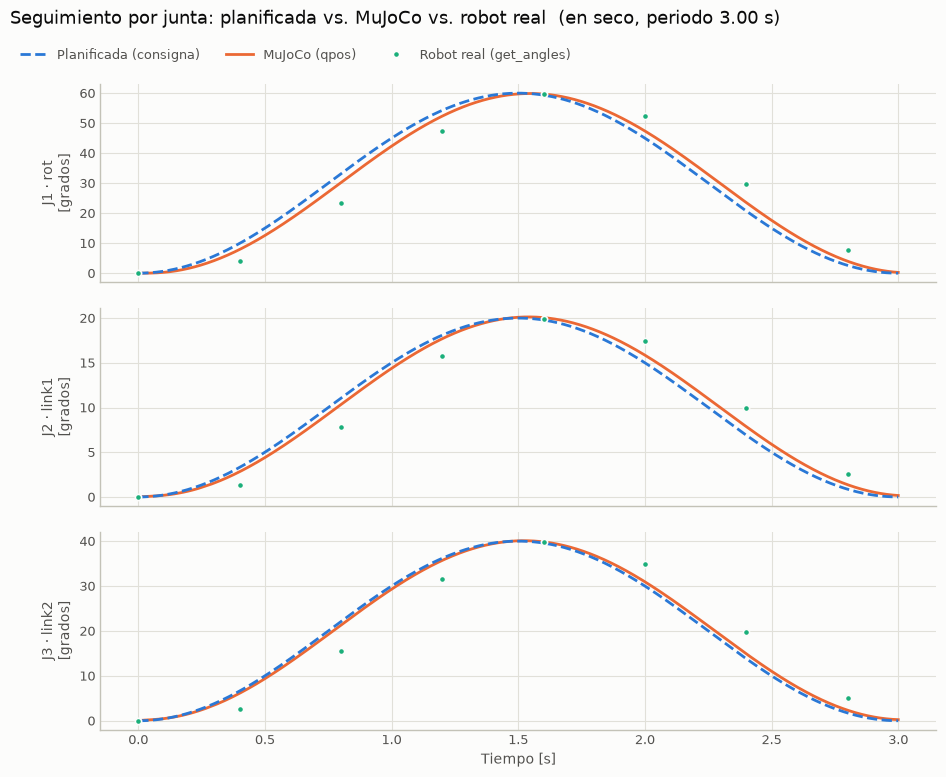

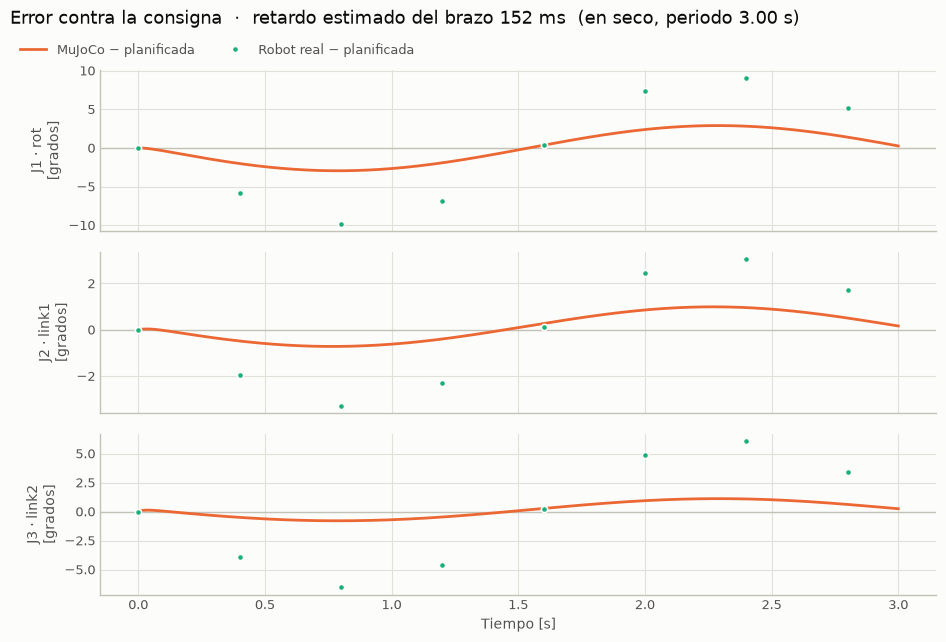

In [197]:
# ===========================================================================
# CORRIDA EN SECO. No abre ningun puerto serie: `DryRunArm` no toca hardware.
# ===========================================================================

# STREAM_RATE_HZ NO ES LA PERILLA DE VELOCIDAD. Es cada cuanto se manda un
# setpoint; subirla manda mas puntos de la MISMA trayectoria, no la acelera.
# Para que el brazo vaya mas rapido se acorta PERIODO_S en la celda de arriba.
#
# Y subirla de mas es contraproducente: a 100 Hz cada vuelta del bucle tiene un
# `send` mas un `get_angles` (que es un viaje de ida y vuelta por el serie), no
# entra en 10 ms, y el bucle se atrasa -- `run_trajectory` lo informa como
# "tasa lograda" muy por debajo de la nominal. Peor: como MyPalletizer260 no
# tiene `set_fresh_mode`, los setpoints de mas se ENCOLAN en el firmware y el
# atraso se acumula durante toda la corrida. 25 Hz sobre un ciclo de 3 s son 75
# muestras, de sobra para un seno.
STREAM_RATE_HZ = 25
STREAM_SPEED = 100        # 1..100 de la API. No es deg/s: es la escala del firmware.

# La guarda corre ANTES que cualquier otra cosa. Si la trayectoria se sale de
# rango -- de posicion O de velocidad -- levanta aca y no llega a existir un
# brazo al que mandarsela. El `t` es lo que le permite chequear la velocidad.
api_deg = check_trajectory(q_target, model, t)

arm = DryRunArm(latency_s=0.08, tau_s=0.06, rate_limit_dps=120.0)
log = run_trajectory(arm, t, q_target, rate_hz=STREAM_RATE_HZ, speed=STREAM_SPEED)
arm.close()

t_sim, q_sim = simulate(model, data, t, q_target)
fig, fig2, lag = plot_three_way(t, q_target, t_sim, q_sim, log,
                                title_suffix=f"  (en seco, periodo {PERIODO_S:.2f} s)")
plt.show()

In [198]:
# ===========================================================================
# CHEQUEOS NEGATIVOS. Una guarda que no puede dispararse no prueba nada.
# ===========================================================================
# Las tres trayectorias de abajo TIENEN que ser rechazadas antes de mandar nada.
# La tercera es la que cubre el caso nuevo: acortar el periodo no mueve ni una
# posicion, asi que solo el chequeo de velocidad la puede atrapar.

print("chequeos negativos (la guarda tiene que disparar en los tres):\n")
_casos = [
    ("J3 llega a 80 deg", [30, 10, 20 * 2], [1.0,  1.0, 1.0], PERIODO_S),
    ("J2 invertida",      [30, 10, 20],     [1.0, -1.0, 1.0], PERIODO_S),
    ("periodo 1.0 s",     [30, 10, 20],     [1.0,  1.0, 1.0], 1.0),
]
for etiqueta, amps_deg, signos, periodo in _casos:
    _signs_backup = SIGNS.copy()
    SIGNS[:] = signos
    try:
        _w = 2 * np.pi / periodo
        _t = np.linspace(0, periodo, int(periodo / dt))
        _amps = np.deg2rad(amps_deg)
        q_malo = np.sin(_w * _t - np.pi / 2)[:, None] * _amps + _amps
        try:
            check_trajectory(q_malo, model, _t, verbose=False)
            print(f"  {etiqueta:20s} NO disparo  <-- MAL, la guarda no sirve")
        except ValueError as exc:
            print(f"  {etiqueta:20s} rechazada OK")
            for linea in str(exc).splitlines()[1:]:
                print(f"      {linea.strip()}")
    finally:
        SIGNS[:] = _signs_backup

# Y el control positivo: sin `t` la guarda NO ve la velocidad, asi que el mismo
# periodo de 1.0 s pasa. Es la razon por la que las dos llamadas de verdad le
# pasan el eje de tiempo.
_w = 2 * np.pi / 1.0
_t = np.linspace(0, 1.0, int(1.0 / dt))
_amps = np.deg2rad([30, 10, 20])
q_rapido = np.sin(_w * _t - np.pi / 2)[:, None] * _amps + _amps
try:
    check_trajectory(q_rapido, model, verbose=False)      # <-- sin t, a proposito
    print("\n  periodo 1.0 s SIN pasarle `t`: pasa la guarda, como se espera.")
    print("  Por eso las llamadas reales usan check_trajectory(q, model, t).")
except ValueError:
    print("\n  <-- inesperado: sin `t` no deberia poder ver la velocidad")

chequeos negativos (la guarda tiene que disparar en los tres):

  J3 llega a 80 deg    rechazada OK
      - J3/link2: recorrido [0.0,80.0] deg fuera del rango del XML [0.0,60.2]
      - J3/link2: recorrido [0.0,80.0] deg fuera del limite de la API [-92.0,60.0]
  J2 invertida         rechazada OK
      - J2/link1: recorrido [-20.0,0.0] deg fuera del rango del XML [0.0,90.0]
      - J2/link1: recorrido [-20.0,0.0] deg fuera del limite de la API [-2.0,90.0]
  periodo 1.0 s        rechazada OK
      - J1/rot: pico de velocidad 188.5 deg/s sobre la spec del brazo (120 deg/s) -- alarga PERIODO_S
      - J3/link2: pico de velocidad 125.7 deg/s sobre la spec del brazo (120 deg/s) -- alarga PERIODO_S

  periodo 1.0 s SIN pasarle `t`: pasa la guarda, como se espera.
  Por eso las llamadas reales usan check_trajectory(q, model, t).


 API XML       recorrido (deg)         rango XML        limite API  pico deg/s   veredicto
J1   rot    [    0.0,   60.0]  [ -159.9,  159.9]  [ -162.0,  162.0]       62.8   OK
J2   link1  [    0.0,   20.0]  [    0.0,   90.0]  [   -2.0,   90.0]       20.9   OK
J3   link2  [    0.0,   40.0]  [    0.0,   60.2]  [  -92.0,   60.0]       41.9   OK
J4   -           (sin modelar)                 -  [ -180.0, 180.0]           -   se mantiene en 0.0 deg
  spec de velocidad del brazo: 120 deg/s
angulos actuales: [-0.26  0.26 -0.26 -0.26]
yendo al inicio [0. 0. 0. 0.] deg a speed=30 ...
angulos al inicio: [-0.26  0.26 -0.26 -0.26]
SerialArm(COM6, speed=100, blocking_send=False)
  setpoints enviados : 76 en 3.001 s
  tasa nominal       : 25.0 Hz
  tasa lograda       : 25.00 Hz (jitter 0.61 ms, peor hueco 42.7 ms)
  lecturas recibidas : 0

RMS contra la consigna [deg]   (rot  link1  link2)
  MuJoCo    : [2.0672 0.6185 0.6927]

  El error grande de J1 en MuJoCo NO es del grafico: `rot_servo` tiene kp=

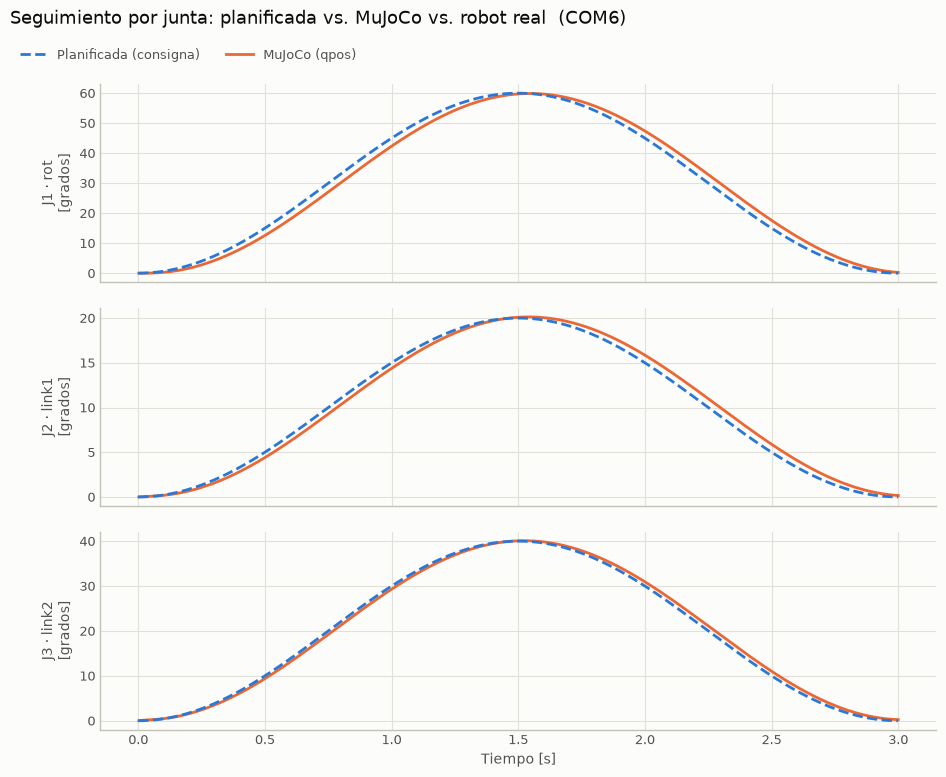

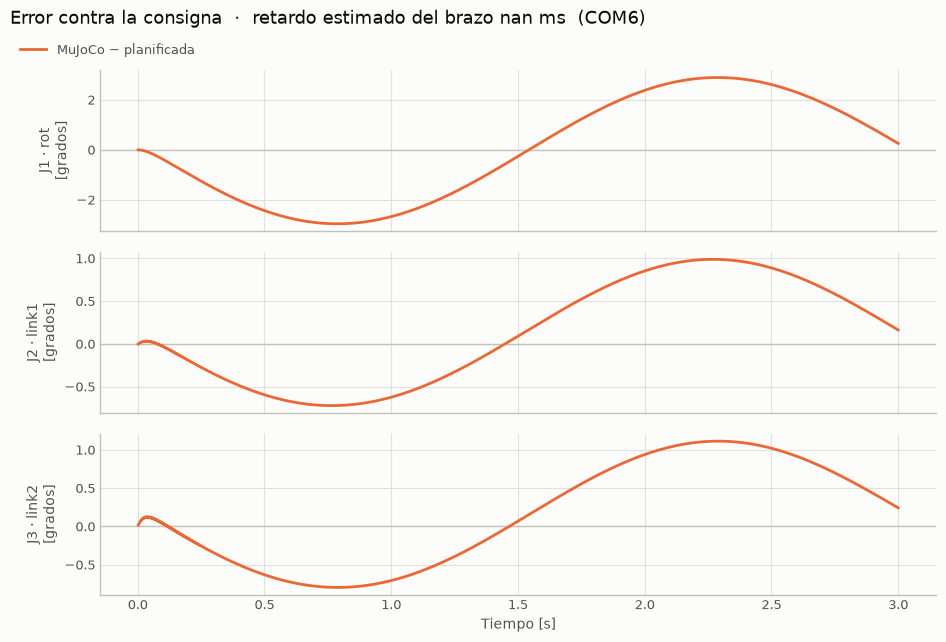

In [199]:
# ===========================================================================
# ROBOT REAL. APAGADO. Correr el notebook entero no abre ningun puerto serie.
# ===========================================================================
#
# Antes de poner SEND_TO_ROBOT = True:
#   - calibracion hecha (los ceros del robot y del modelo coinciden);
#   - espacio libre alrededor: J1 barre 60 deg desde el `home`;
#   - la celda de arriba corrio y la trayectoria dio OK en la tabla;
#   - una mano en el boton de apagado la primera vez.
#
# El brazo arranca donde este, no en `home`. El primer setpoint es [0,0,0] deg,
# asi que si esta lejos, el primer movimiento es el mas grande de todo el
# barrido y lo hace a `speed` -- por eso el `send_angles` de posicionamiento
# inicial, que es BLOQUEANTE y espera a que llegue antes de empezar a barrer.

SEND_TO_ROBOT = True        # <-- el unico interruptor
PORT = "COM6"                # el mismo de Palletizer.ipynb
HOMING_SPEED = 30            # 1..100. DESPACIO a proposito: este movimiento
                             # es el unico sin perfil -- va de donde este el
                             # brazo hasta [0,0,0] en linea recta de juntas, y
                             # puede ser mas grande que todo el barrido junto.

if SEND_TO_ROBOT:
    api_deg = check_trajectory(q_target, model, t)

    arm = SerialArm(PORT, speed=STREAM_SPEED, blocking_send=False)
    try:
        print("angulos actuales:", arm.read())
        print(f"yendo al inicio {api_deg[0]} deg a speed={HOMING_SPEED} ...")
        arm.mc.sync_send_angles([float(d) for d in api_deg[0]], HOMING_SPEED)
        time.sleep(0.5)
        print("angulos al inicio:", arm.read())

        log_real = run_trajectory(arm, t, q_target, rate_hz=STREAM_RATE_HZ, read=False,
                                  speed=STREAM_SPEED)
    finally:
        arm.close()                                  # el puerto se cierra igual

    t_sim, q_sim = simulate(model, data, t, q_target)
    fig, fig2, lag = plot_three_way(t, q_target, t_sim, q_sim, log_real,
                                    title_suffix=f"  ({PORT})")
    plt.show()

    np.savez_compressed(repo_root / "data" / "raw" / "palletizer_traj.npz",
                        t=t, q_target=q_target, t_sim=t_sim, q_sim=q_sim,
                        t_cmd=log_real["t_cmd"], q_cmd_deg=log_real["q_cmd_deg"],
                        t_meas=log_real["t_meas"], q_meas_deg=log_real["q_meas_deg"])
else:
    print("SEND_TO_ROBOT = False -> no se abrio ningun puerto serie.")

In [201]:
# ===========================================================================
# ROBOT REAL + LOG DE IMUs, log acotado a la ventana de la trayectoria.
# ===========================================================================
#
# Dos bugs de la version anterior:
#
# 1. Reusaba el `arm` de la celda "ROBOT REAL. APAGADO." de arriba, pero esa
#    celda ya lo cerro en su `finally` -- `arm.read()` aca pegaba contra un
#    puerto cerrado y el brazo no se movia. Esta celda abre su PROPIA conexion.
# 2. El logging arrancaba con la PRIMERA linea de IMU valida, que llega antes
#    del homing. `trajectory_started` / `trajectory_done` delimitan la ventana
#    real (las prende/apaga el thread del robot, justo antes/despues de
#    `run_trajectory`) y el loop que lee el puerto serie de las IMUs solo
#    guarda filas mientras esa ventana esta abierta.
#
# RUN_ROBOT_WITH_IMU es el interruptor, en False por default a proposito --
# esto mueve el brazo real. Ponelo en True solo con espacio libre alrededor y
# la calibracion hecha (mismo checklist que la celda de arriba).

import re
import serial
import threading

RUN_ROBOT_WITH_IMU = True
ROBOT_PORT = "COM6"          # mismo puerto de brazo que el resto del notebook
IMU_PORT = "COM7"            # puerto del arduino con las dos IMUs
IMU_BAUDRATE = 9600
HOMING_SPEED = 30            # ver celda "ROBOT REAL. APAGADO." -- despacio a proposito

IMU_KEYS = [
    "IMU_0.ax", "IMU_0.ay", "IMU_0.az",
    "IMU_1.ax", "IMU_1.ay", "IMU_1.az",
    "IMU_0.wx", "IMU_0.wy", "IMU_0.wz",
    "IMU_1.wx", "IMU_1.wy", "IMU_1.wz",
]
TIMESTAMP_KEYS = ["t", "ts", "timestamp", "time", "millis"]


def parse_imu_line(line):
    pairs = re.findall(r'([A-Za-z0-9_.]+):([-+]?\d*\.?\d+)', line)
    if not pairs:
        return None, None
    data_dict = {key: float(val) for key, val in pairs}
    if all(k in data_dict for k in IMU_KEYS):
        hw_timestamp = next((data_dict[tk] for tk in TIMESTAMP_KEYS if tk in data_dict), None)
        return data_dict, hw_timestamp
    return None, None


def extract_imu_vector(data_dict):
    return np.array([data_dict[k] for k in IMU_KEYS], dtype=np.float64)


trajectory_started = threading.Event()   # el brazo ya homeo, run_trajectory arranca
trajectory_done = threading.Event()      # run_trajectory termino
stop_logging = threading.Event()         # el thread del robot cerro todo, cortar el loop
robot_result = {}
recorded_imu_data = []


def execute_robot_trajectory():
    arm = SerialArm(ROBOT_PORT, speed=STREAM_SPEED, blocking_send=False)
    try:
        api_deg = check_trajectory(q_target, model, t)
        print(f"[ROBOT] angulos actuales: {arm.read()}")
        print(f"[ROBOT] yendo al inicio {api_deg[0]} deg a speed={HOMING_SPEED} ...")
        arm.mc.sync_send_angles([float(d) for d in api_deg[0]], HOMING_SPEED)
        time.sleep(0.5)
        print(f"[ROBOT] angulos al inicio: {arm.read()}")

        trajectory_started.set()
        print("[ROBOT] iniciando run_trajectory -- arranca el log de IMUs...")
        robot_result["log_real"] = run_trajectory(
            arm, t, q_target, rate_hz=STREAM_RATE_HZ, read=False, speed=STREAM_SPEED)
        print("[ROBOT] trayectoria terminada -- corta el log de IMUs.")
    finally:
        trajectory_done.set()
        arm.close()
        stop_logging.set()


if RUN_ROBOT_WITH_IMU:
    ser = serial.Serial(IMU_PORT, baudrate=IMU_BAUDRATE, timeout=1.0)
    ser.reset_input_buffer()

    print("Esperando que las IMUs empiecen a transmitir...")
    imu_ready = False
    robot_thread = None
    t0 = None

    try:
        while not stop_logging.is_set():
            if ser.in_waiting > 0:
                raw_line = ser.readline().decode("utf-8", errors="ignore").strip()
                imu_dict, hw_timestamp = parse_imu_line(raw_line)

                if imu_dict:
                    if not imu_ready:
                        imu_ready = True
                        t0 = time.perf_counter()
                        print("\nIMUs listas -- arrancando el thread del robot "
                              "(el log todavia NO arranca: falta el homing).\n")
                        robot_thread = threading.Thread(target=execute_robot_trajectory)
                        robot_thread.start()

                    # Ventana de log: solo entre "ya homeo" y "trayectoria termino".
                    if trajectory_started.is_set() and not trajectory_done.is_set():
                        timestamp = hw_timestamp if hw_timestamp is not None \
                            else time.perf_counter() - t0
                        row_data = [timestamp] + extract_imu_vector(imu_dict).tolist()
                        recorded_imu_data.append(row_data)
                else:
                    if raw_line:
                        prefix = "[DEBUG]" if imu_ready else "[INIT]"
                        print(f"{prefix}: {raw_line}")
    except KeyboardInterrupt:
        print("\nForzando parada por teclado.")
        stop_logging.set()
    finally:
        ser.close()
        if robot_thread is not None:
            robot_thread.join()
else:
    print("RUN_ROBOT_WITH_IMU = False -> no se abrio ningun puerto serie, "
          "no se movio nada.")

# --- Guardar el log como CSV. Corre siempre: log vacio si no se corrio nada. ---
if len(recorded_imu_data) > 0:
    imu_log = np.array(recorded_imu_data)
    header_str = "timestamp," + ",".join(IMU_KEYS)
    csv_path = repo_root / "data" / "raw" / "imu_trajectory_log.csv"
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    np.savetxt(csv_path, imu_log, delimiter=",", header=header_str, comments="")
    print(f"Guardadas {imu_log.shape[0]} muestras de IMU (solo durante la "
          f"trayectoria) en {csv_path}")
else:
    imu_log = np.empty((0, 1 + len(IMU_KEYS)))
    print("No se registro ninguna muestra de IMU durante la trayectoria.")

Esperando que las IMUs empiecen a transmitir...
[INIT]: HELLO, This is Eris
[INIT]: TInitializing IMU
[INIT]:  TInitializing IMU 0
[INIT]:  
[INIT]: TIMU 0: OK
[INIT]:  TInitializing IMU 1
[INIT]:  
[INIT]: TIMU 1: OK
[INIT]:  IMU ready
[INIT]: Serial Commands are ready
[INIT]: Function requested: IMU_0
[INIT]: IMU_0 selected
[INIT]: Function requested: IMU_1
[INIT]: IMU_1 selected

IMUs listas -- arrancando el thread del robot (el log todavia NO arranca: falta el homing).

 API XML       recorrido (deg)         rango XML        limite API  pico deg/s   veredicto
J1   rot    [    0.0,   60.0]  [ -159.9,  159.9]  [ -162.0,  162.0]       62.8   OK
J2   link1  [    0.0,   20.0]  [    0.0,   90.0]  [   -2.0,   90.0]       20.9   OK
J3   link2  [    0.0,   40.0]  [    0.0,   60.2]  [  -92.0,   60.0]       41.9   OK
J4   -           (sin modelar)                 -  [ -180.0, 180.0]           -   se mantiene en 0.0 deg
  spec de velocidad del brazo: 120 deg/s
[ROBOT] angulos actuales: [ 0.

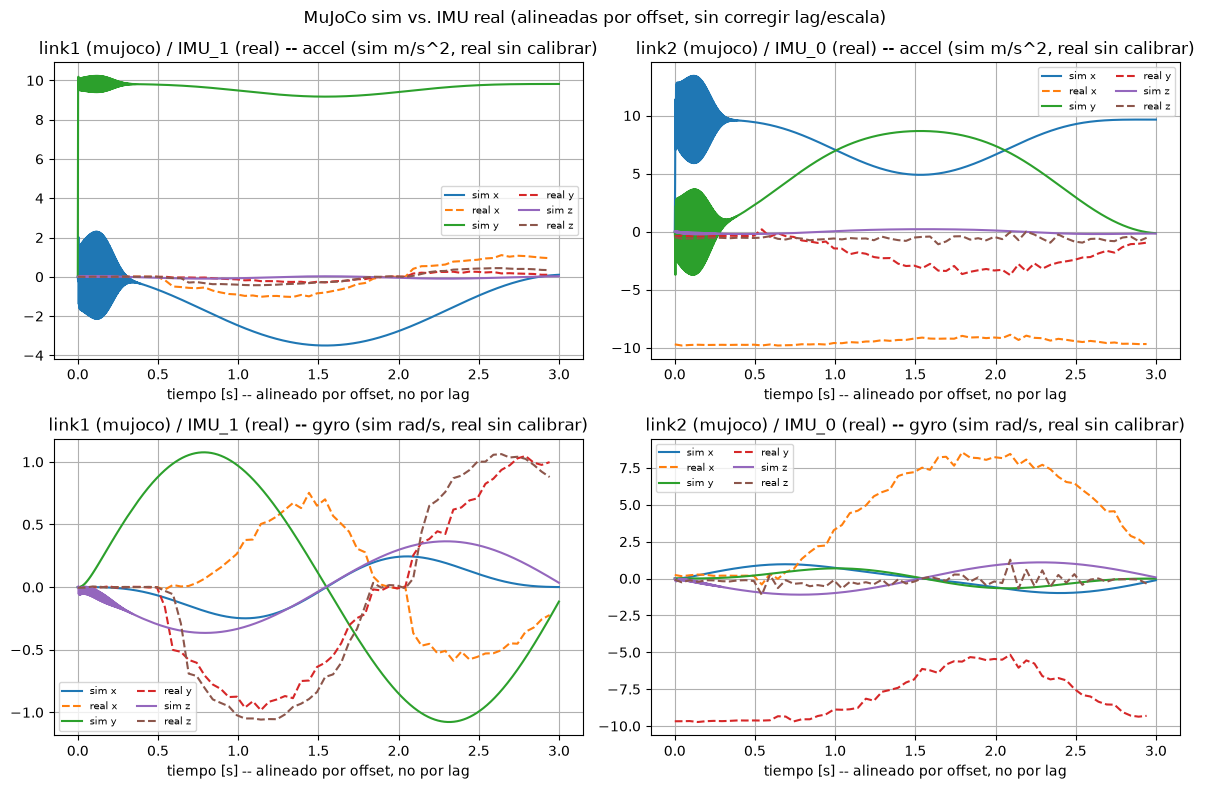

In [202]:
# ===========================================================================
# Sim (MuJoCo) vs. IMU real -- alineadas solo por OFFSET, no por lag ni escala.
# ===========================================================================
# Cada IMU trae 3 accel + 3 gyro; link1_acc_history / link1_gyro_history / etc.
# vienen de la celda de simulacion de mas arriba. Los paneles van por junta del
# MODELO (mujoco fijo en su columna); lo que se intercambio es la IMU real que
# se le empareja: IMU_1 -> link1, IMU_0 -> link2 (al reves de como estan
# cableadas/numeradas -- ver el comentario en IMU_KEYS si esto vuelve a
# cambiar).
#
# `imu_t` arranca en el sello de tiempo de la PRIMERA fila registrada -- que ya
# es el instante en que `run_trajectory` empezo a mandar (la celda anterior
# solo guarda filas dentro de esa ventana) -- asi que restarle ese primer valor
# pone a las dos series en t=0 en el mismo evento: arranque de la trayectoria.
# Esto NO corrige el retardo del brazo real ni la deriva de reloj -- para eso
# esta `estimate_lag`, igual que en `plot_three_way`. La escala/unidades de la
# IMU real tampoco estan calibradas contra MuJoCo todavia.

if imu_log.shape[0] == 0:
    print("No hay datos de IMU real para graficar (RUN_ROBOT_WITH_IMU=False o "
          "no se registro nada en la celda anterior).")
else:
    imu_t = imu_log[:, 0] - imu_log[0, 0]   # offset: arranca en 0, como `t`
    imu_0 = imu_log[:, 1:7]     # ax,ay,az,wx,wy,wz de IMU_0 -- emparejada con link2
    imu_1 = imu_log[:, 7:13]    # ax,ay,az,wx,wy,wz de IMU_1 -- emparejada con link1

    panels = [
        (link1_acc_history, link1_gyro_history, imu_1, "link1 (mujoco) / IMU_1 (real)"),
        (link2_acc_history, link2_gyro_history, imu_0, "link2 (mujoco) / IMU_0 (real)"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for col, (sim_acc, sim_gyro, imu_block, label) in enumerate(panels):
        ax_acc, ax_gyro = axes[0, col], axes[1, col]
        for k, axis_name in enumerate("xyz"):
            ax_acc.plot(t, sim_acc[:, k], label=f"sim {axis_name}")
            ax_acc.plot(imu_t, imu_block[:, k], "--", label=f"real {axis_name}")
            ax_gyro.plot(t, sim_gyro[:, k], label=f"sim {axis_name}")
            ax_gyro.plot(imu_t, imu_block[:, 3 + k], "--", label=f"real {axis_name}")
        ax_acc.set_title(f"{label} -- accel (sim m/s^2, real sin calibrar)")
        ax_gyro.set_title(f"{label} -- gyro (sim rad/s, real sin calibrar)")
        ax_acc.set_xlabel("tiempo [s] -- alineado por offset, no por lag")
        ax_gyro.set_xlabel("tiempo [s] -- alineado por offset, no por lag")
        ax_acc.legend(fontsize=7, ncols=2)
        ax_gyro.legend(fontsize=7, ncols=2)
        ax_acc.grid(True)
        ax_gyro.grid(True)
    fig.suptitle("MuJoCo sim vs. IMU real (alineadas por offset, sin corregir lag/escala)")
    fig.tight_layout()
    plt.show()